<a href="https://colab.research.google.com/github/teoteoh/sctec_aulas/blob/main/Miniprojeto_TeodoraCosta_Analise_de_Dados_TI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importando as bibliotecas relevantes:

In [50]:
import csv
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

Carregando CSV e fazendo as primeiras
inspeções:

In [51]:
df = pd.read_csv('Base Varejo.csv', sep=';')

display(df.head())


,DATA,CO_ID,CL_ID,CL_GENERO,CL_EC,CL_FHL,CL_SEG,PR_ID,PR_CAT,PR_NOME,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13
0,01/02/2019,1000,534,M,4,1,C,67,BEBIDAS,REFRIGERANTE GUARANA,NaN,NaN,NaN,NaN
1,01/02/2019,1000,534,M,4,1,C,70,BEBIDAS,REFRIGERANTE OUTROS,NaN,NaN,NaN,NaN
2,01/02/2019,1000,534,M,4,1,C,178,HIGIENE,LENCO UMEDECIDO,NaN,NaN,NaN,NaN
3,01/02/2019,1000,534,M,4,1,C,4,ALIMENTOS,ABACAXI,NaN,NaN,NaN,NaN
4,01/02/2019,1000,534,M,4,1,C,175,LIMPEZA,LIMPADOR MULTIUSO,NaN,NaN,NaN,NaN


In [52]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 830000 entries, 0 to 829999
Data columns (total 14 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   DATA         830000 non-null  object 
 1   CO_ID        830000 non-null  int64  
 2   CL_ID        830000 non-null  int64  
 3   CL_GENERO    830000 non-null  object 
 4   CL_EC        830000 non-null  int64  
 5   CL_FHL       830000 non-null  int64  
 6   CL_SEG       830000 non-null  object 
 7   PR_ID        830000 non-null  int64  
 8   PR_CAT       830000 non-null  object 
 9   PR_NOME      830000 non-null  object 
 10  Unnamed: 10  0 non-null       float64
 11  Unnamed: 11  0 non-null       float64
 12  Unnamed: 12  0 non-null       float64
 13  Unnamed: 13  0 non-null       float64
dtypes: float64(4), int64(5), object(5)
memory usage: 88.7+ MB
None


Há colunas sem rótulo e com valores vazios. Fazemos a remoção das colunas vazias para manter a base de dados mais limpa e concisa:

In [53]:
df = df.dropna(axis=1, how='all')

Checamos para ver se há linhas duplicadas:

In [54]:
if df.duplicated().sum() > 0:
    print(f"Linhas duplicadas: {df.duplicated().sum()}")
else:
    print("\nNão há duplicatas.")

Linhas duplicadas: 96553


Agora removemos duplicatas e checamos o resultado:

In [55]:
df = df.drop_duplicates()

print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 733447 entries, 0 to 829999
Data columns (total 10 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   DATA       733447 non-null  object
 1   CO_ID      733447 non-null  int64 
 2   CL_ID      733447 non-null  int64 
 3   CL_GENERO  733447 non-null  object
 4   CL_EC      733447 non-null  int64 
 5   CL_FHL     733447 non-null  int64 
 6   CL_SEG     733447 non-null  object
 7   PR_ID      733447 non-null  int64 
 8   PR_CAT     733447 non-null  object
 9   PR_NOME    733447 non-null  object
dtypes: int64(5), object(5)
memory usage: 61.6+ MB
None


Transformando a coluna DATA em DataTime:

In [56]:
df['DATA'] = pd.to_datetime(df['DATA'], format='%d/%m/%Y')

display(df.head())
print(df['DATA'].dtype)

,DATA,CO_ID,CL_ID,CL_GENERO,CL_EC,CL_FHL,CL_SEG,PR_ID,PR_CAT,PR_NOME
0,2019-02-01,1000,534,M,4,1,C,67,BEBIDAS,REFRIGERANTE GUARANA
1,2019-02-01,1000,534,M,4,1,C,70,BEBIDAS,REFRIGERANTE OUTROS
2,2019-02-01,1000,534,M,4,1,C,178,HIGIENE,LENCO UMEDECIDO
3,2019-02-01,1000,534,M,4,1,C,4,ALIMENTOS,ABACAXI
4,2019-02-01,1000,534,M,4,1,C,175,LIMPEZA,LIMPADOR MULTIUSO


datetime64[ns]


Agora verificamos se há categorias vazias:

In [57]:
print("NaN por coluna:")
print(df.isna().sum())

print("Strings por coluna:")
for col in df.select_dtypes(include=['object']).columns:
    vazios = (df[col].astype(str).str.strip() == '').sum()
    if vazios > 0:
        print(f"{col}: {vazios} registros vazios.")
    else:
        print(f"{col}: Nenhum registro vazio.")

NaN por coluna:
DATA         0
CO_ID        0
CL_ID        0
CL_GENERO    0
CL_EC        0
CL_FHL       0
CL_SEG       0
PR_ID        0
PR_CAT       0
PR_NOME      0
dtype: int64
Strings por coluna:
CL_GENERO: Nenhum registro vazio.
CL_SEG: Nenhum registro vazio.
PR_CAT: Nenhum registro vazio.
PR_NOME: Nenhum registro vazio.


Substituimos os NaN por "Sem Categoria" e checamos o resultado:

In [58]:
#df = df.fillna('Sem Categoria')

#print(f"Valores vazios: {df.isna().sum().sum()}")

Estatísticas básicas relacionadas ao número de filhos dos clientes:

In [59]:
stats = df['CL_FHL'].describe()
mode_val = df['CL_FHL'].mode()[0]
median_val = df['CL_FHL'].median()

print("Estatísticas Descritivas Referentes ao Número de Filhos:")
print(f"Contagem:        {stats['count']}")
print(f"Média:           {stats['mean']:.2f}")
print(f"Mediana:         {median_val}")
print(f"Moda:            {mode_val}")
print(f"Desvio Padrão:   {stats['std']:.2f}")
print(f"Mínimo:          {stats['min']}")
print(f"Máximo:          {stats['max']}")
print(f"Quartil 25%:     {stats['25%']}")
print(f"Quartil 50%:     {stats['50%']}")
print(f"Quartil 75%:     {stats['75%']}")

Estatísticas Descritivas Referentes ao Número de Filhos:
Contagem:        733447.0
Média:           1.15
Mediana:         0.0
Moda:            0
Desvio Padrão:   1.42
Mínimo:          0.0
Máximo:          4.0
Quartil 25%:     0.0
Quartil 50%:     0.0
Quartil 75%:     2.0


Agora agrupamos os principais produtos por gênero:

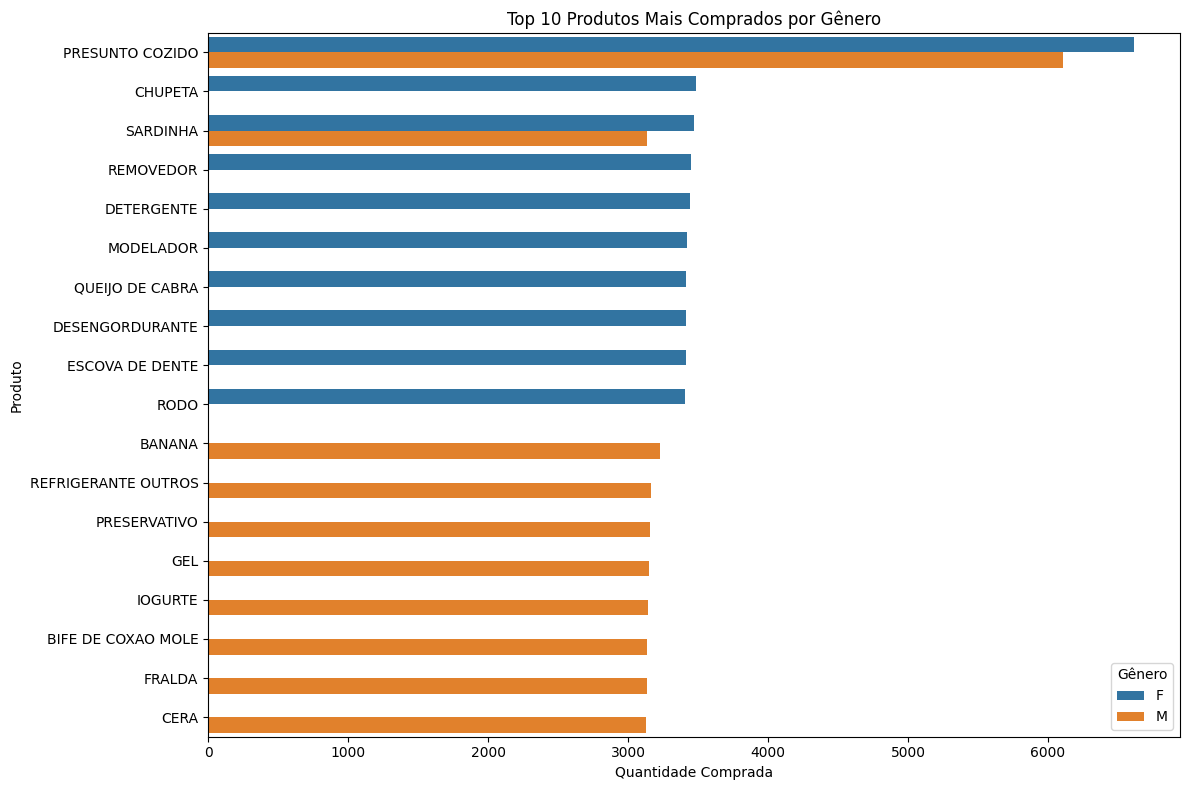

In [60]:
produtos_por_genero = df.groupby(['CL_GENERO', 'PR_NOME']).size().reset_index(name='QUANTIDADE')
grupos = produtos_por_genero.groupby('CL_GENERO')
top_10_por_genero = pd.concat([grupo.nlargest(10, 'QUANTIDADE') for _, grupo in grupos]).reset_index(drop=True)

plt.figure(figsize=(12, 8))
sns.barplot(data=top_10_por_genero, x='QUANTIDADE', y='PR_NOME', hue='CL_GENERO')

plt.title('Top 10 Produtos Mais Comprados por Gênero')
plt.xlabel('Quantidade Comprada')
plt.ylabel('Produto')
plt.legend(title='Gênero')
plt.tight_layout()
plt.show()

Agrupamos os principais produtos por segmento social:

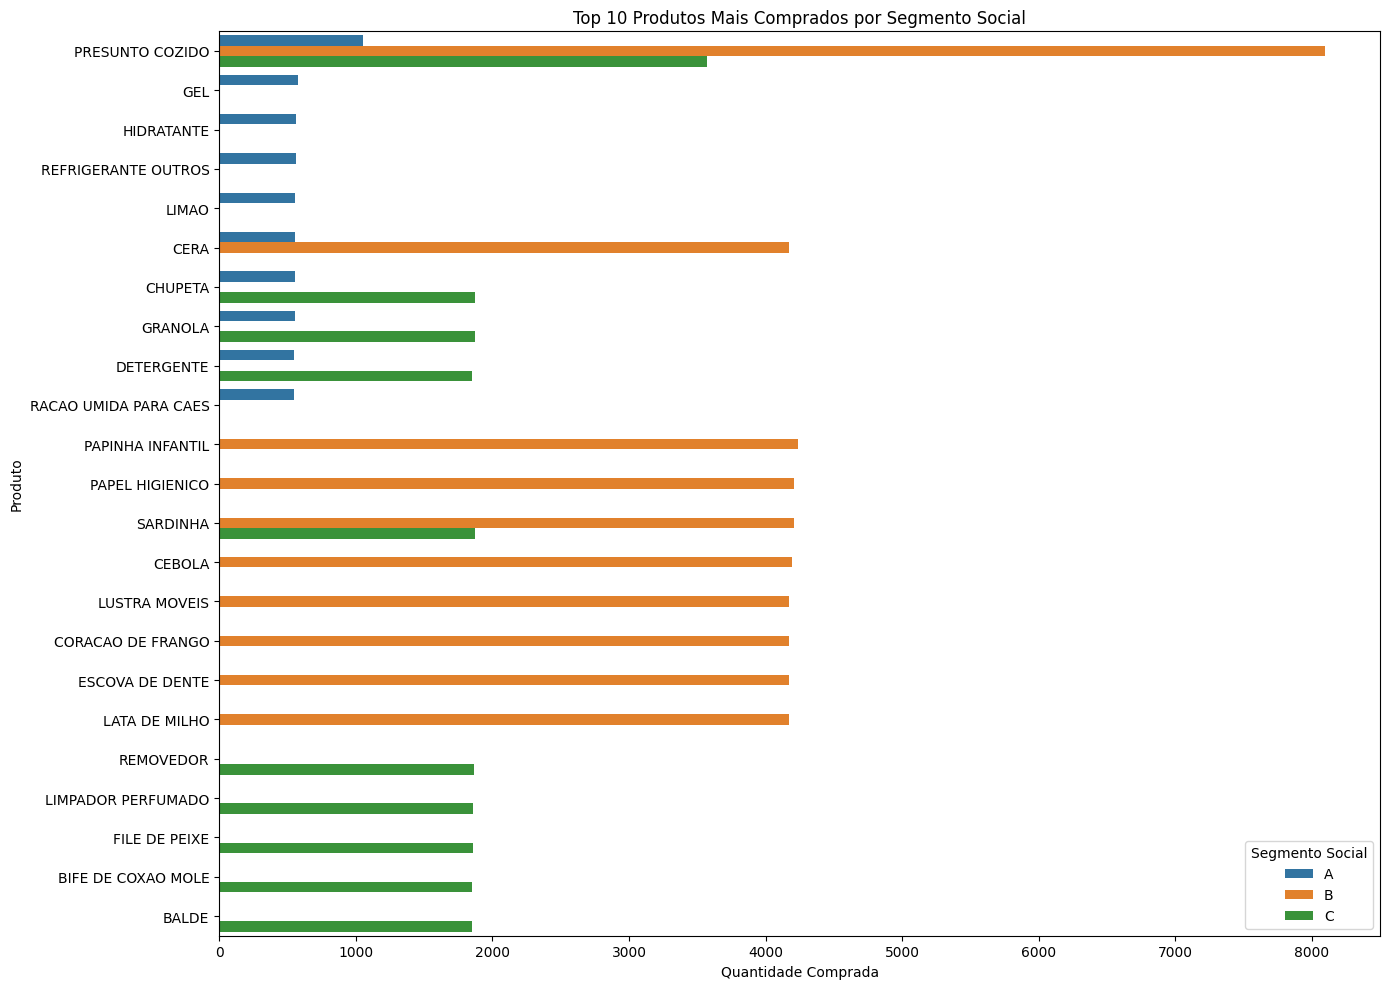

In [61]:
produtos_por_segmento = df.groupby(['CL_SEG', 'PR_NOME']).size().reset_index(name='QUANTIDADE')

grupos_seg = produtos_por_segmento.groupby('CL_SEG')
top_10_por_segmento = pd.concat([grupo.nlargest(10, 'QUANTIDADE') for _, grupo in grupos_seg]).reset_index(drop=True)

plt.figure(figsize=(14, 10))
sns.barplot(data=top_10_por_segmento, x='QUANTIDADE', y='PR_NOME', hue='CL_SEG')

plt.title('Top 10 Produtos Mais Comprados por Segmento Social')
plt.xlabel('Quantidade Comprada')
plt.ylabel('Produto')
plt.legend(title='Segmento Social')
plt.tight_layout()
plt.show()

/tmp/ipykernel_1736/774548221.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_prod_comparativo = prod_seg_gen.groupby(['CL_SEG', 'CL_GENERO']).apply(lambda x: x.nlargest(5, 'QUANTIDADE')).reset_index(drop=True)


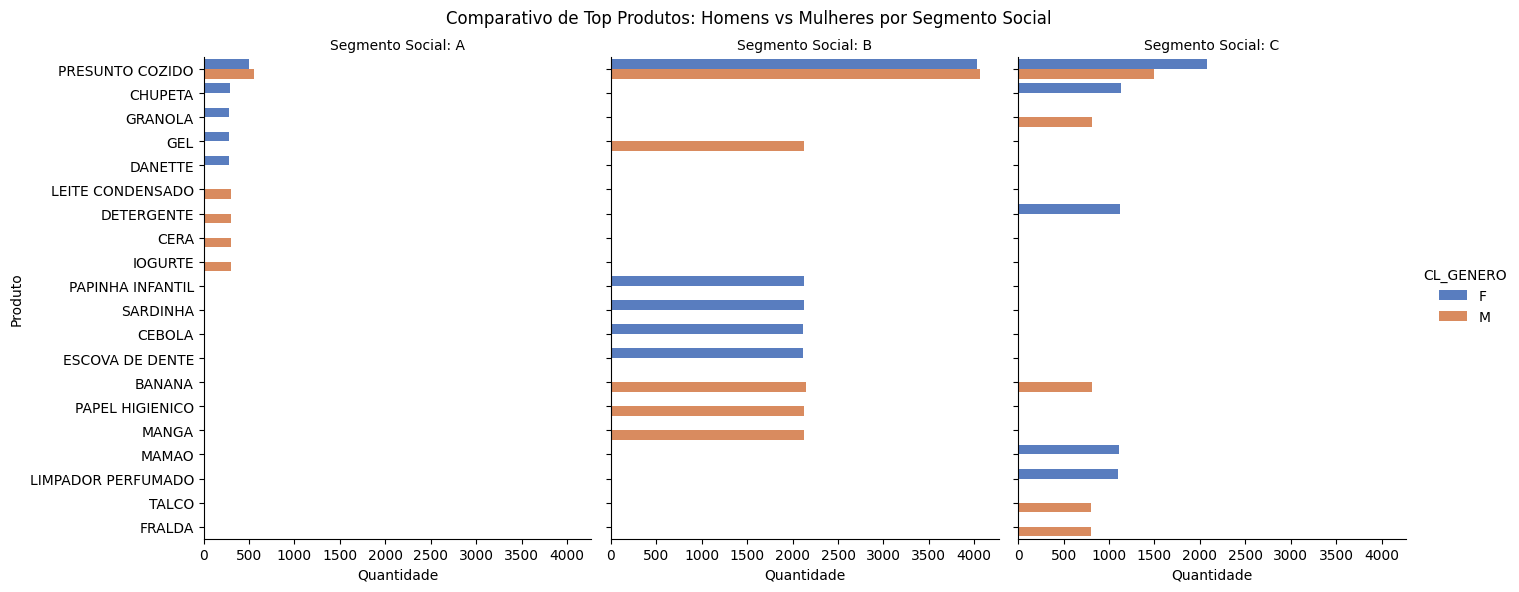

In [62]:
prod_seg_gen = df.groupby(['CL_SEG', 'CL_GENERO', 'PR_NOME']).size().reset_index(name='QUANTIDADE')

top_prod_comparativo = prod_seg_gen.groupby(['CL_SEG', 'CL_GENERO']).apply(lambda x: x.nlargest(5, 'QUANTIDADE')).reset_index(drop=True)

g = sns.catplot(
    data=top_prod_comparativo,
    kind="bar",
    x="QUANTIDADE", y="PR_NOME",
    hue="CL_GENERO", col="CL_SEG",
    palette="muted", height=6, aspect=0.8
)

g.set_titles("Segmento Social: {col_name}")
g.set_axis_labels("Quantidade", "Produto")
plt.subplots_adjust(top=0.9)
g.fig.suptitle('Comparativo de Top Produtos: Homens vs Mulheres por Segmento Social')
plt.show()

Insights com base nos gráficos gerados:

1.   Preseunto cozido e sardinha são dois produtos que tanto homens quanto mulheres compram em quase a mesma quantidade, independente do segmento social. Aumentar a oferta e a variedade desses produtos pode gerar um lucro maior para o negócio.
2.   Os principais produtos comprados por mulheres tendem a incluir mais produtos de higiene e limpeza do que produtos comprados por homens. Isso indica que os papéis de gênero influenciam significativamente as compras, e que mulheres ainda são as principais responsáveis pela limpeza do ambiente.
3.  Percebe-se que mulheres da classe social C compram mais produtos de limpeza do que mulheres da classe social A e B. Isso indica que mulheres de classes sociais mais altas não são responsáveis por limpeza. Oferecer promoções e ofertas de produtos de limpeza pode deixar os protudos mais acessíveis ao principal segmento que os consome.
4.  Homens do segmento social C são responsáveis por adquirir produtos de higiene para bebês. Isso indica que o gráfico se passa em uma realidade alternativa em que homens são os principais cuidadores dos filhos durante os primeiros anos de suas vidas. Ou que, no caso de casais, são os homens que arcam com as despesas relacionadas aos bebês.

